In [1]:
# Dataset Analysis: Brain Tumor & KITTI
# Comprehensive exploratory data analysis with visualizations

import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import yaml
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── CPU-aware batch / worker config ──────────────────────────────────────────
# i5-1335U: 10 cores / 12 logical processors.
# We leave 2 logical processors free for the OS & other processes.
TOTAL_LOGICAL = os.cpu_count() or 12   # 12 on your machine
MAX_WORKERS   = max(1, TOTAL_LOGICAL - 2)  # → 10 workers
BATCH_SIZE    = MAX_WORKERS             # images processed per batch → 10
print(f"CPU logical processors : {TOTAL_LOGICAL}")
print(f"Workers used           : {MAX_WORKERS}")
print(f"Batch size             : {BATCH_SIZE}")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ── Output directory ─────────────────────────────────────────────────────────
# ── Paths: resolve everything relative to THIS notebook file ────────────────
# Works no matter where Jupyter is launched from.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent   # when run as a script
except NameError:
    # Inside Jupyter, __file__ is undefined.
    # Jupyter sets cwd to the folder containing the .ipynb, so this is reliable.
    NOTEBOOK_DIR = Path.cwd()

VISUALS_DIR = Path('..') / 'visuals' / 'analysis'
VISUALS_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nVisuals will be saved to: {VISUALS_DIR.resolve()}")
print("✓ Libraries loaded successfully")

CPU logical processors : 28
Workers used           : 26
Batch size             : 26

Visuals will be saved to: E:\ScaleVision\visuals\analysis
✓ Libraries loaded successfully


In [2]:
# Define dataset paths
BASE_DIR        = Path('..') / 'datasets'
BRAIN_TUMOR_DIR = BASE_DIR / 'brain_tumor'
KITTI_DIR       = BASE_DIR / 'kitti'

print(f"Project root : {NOTEBOOK_DIR}")
print(f"Datasets dir : {BASE_DIR}")
print(f"Brain Tumor  : {BRAIN_TUMOR_DIR}")
print(f"KITTI        : {KITTI_DIR}")
print(f"Visuals out  : {VISUALS_DIR}")

# Load YAML configs — search both dataset root and one level up
def _load_yaml(primary_path, fallback_name):
    """Try primary path; if missing, search the datasets folder."""
    if primary_path.exists():
        with open(primary_path, 'r', encoding='utf-8') as f:
            return yaml.safe_load(f)
    # Fallback: scan BASE_DIR recursively for the yaml
    matches = list(BASE_DIR.rglob(fallback_name))
    if matches:
        print(f"  ⚠️  YAML not at expected path; found at {matches[0]}")
        with open(matches[0], 'r', encoding='utf-8') as f:
            return yaml.safe_load(f)
    raise FileNotFoundError(
        f"Cannot find {fallback_name} anywhere under {BASE_DIR}.\n"
        f"Expected: {primary_path}\n"
        f"Place the YAML file there and re-run this cell."
    )

brain_tumor_config = _load_yaml(BRAIN_TUMOR_DIR / 'brain-tumor.yaml', 'brain-tumor.yaml')
kitti_config       = _load_yaml(KITTI_DIR       / 'kitti.yaml',       'kitti.yaml')

print("Brain Tumor Dataset Config:")
print(f"  Classes: {brain_tumor_config['names']}")
print(f"  Train/Val images: {brain_tumor_config['train']}, {brain_tumor_config['val']}")
print("\nKITTI Dataset Config:")
print(f"  Classes: {kitti_config['names']}")
print(f"  Train/Val images: {kitti_config['train']}, {kitti_config['val']}")

Project root : e:\ScaleVision\notebook
Datasets dir : ..\datasets
Brain Tumor  : ..\datasets\brain_tumor
KITTI        : ..\datasets\kitti
Visuals out  : ..\visuals\analysis
Brain Tumor Dataset Config:
  Classes: {0: 'negative', 1: 'positive'}
  Train/Val images: images/train, images/val

KITTI Dataset Config:
  Classes: {0: 'car', 1: 'van', 2: 'truck', 3: 'pedestrian', 4: 'Person_sitting', 5: 'cyclist', 6: 'tram', 7: 'misc'}
  Train/Val images: images/train, images/val


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────

# ── Image-format detection ───────────────────────────────────────────────────
IMG_EXTS = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif', '*.tiff')

def get_image_files(directory):
    """Return all image files in directory regardless of extension."""
    d = Path(directory)
    if not d.exists():
        return []
    files = []
    for ext in IMG_EXTS:
        files.extend(d.glob(ext))
    return files


def load_yolo_labels(label_dir):
    """Load YOLO format labels with tqdm progress."""
    labels_data = []
    label_path  = Path(label_dir)
    if not label_path.exists():
        return labels_data

    label_files = list(label_path.glob('*.txt'))
    for label_file in tqdm(label_files, desc=f'Loading labels [{label_path.parent.name}/{label_path.name}]', leave=False):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    labels_data.append({
                        'file'    : label_file.stem,
                        'class'   : int(parts[0]),
                        'x_center': float(parts[1]),
                        'y_center': float(parts[2]),
                        'width'   : float(parts[3]),
                        'height'  : float(parts[4])
                    })
    return labels_data


def _stat_one_image(img_file):
    """Open a single image and return its stats (used in thread pool)."""
    try:
        img = Image.open(img_file)
        return {
            'file'   : img_file.stem,
            'width'  : img.width,
            'height' : img.height,
            'size_mb': img_file.stat().st_size / (1024 * 1024),
            'format' : img.format
        }
    except Exception as e:
        print(f"Error loading {img_file}: {e}")
        return None


def get_image_stats(image_dir):
    """Get statistics for images using batched thread pool + tqdm."""
    img_dir = Path(image_dir)
    if not img_dir.exists():
        return []

    all_files = get_image_files(img_dir)
    stats     = []

    # Process in batches of BATCH_SIZE so RAM / thread overhead stays bounded
    batches = [all_files[i:i + BATCH_SIZE] for i in range(0, len(all_files), BATCH_SIZE)]
    desc    = f'Image stats [{img_dir.parent.name}/{img_dir.name}]'

    with tqdm(total=len(all_files), desc=desc, leave=False) as pbar:
        for batch in batches:
            with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
                futures = {executor.submit(_stat_one_image, f): f for f in batch}
                for future in as_completed(futures):
                    result = future.result()
                    if result:
                        stats.append(result)
                    pbar.update(1)
    return stats


def get_dataset_stats(dataset_dir, dataset_name):
    """Comprehensive dataset statistics."""
    stats = {}
    for split in tqdm(['train', 'val'], desc=f'Scanning {dataset_name}'):
        split_dir = dataset_dir / 'images' / split
        label_dir = dataset_dir / 'labels' / split

        image_count = len(get_image_files(split_dir)) if split_dir.exists() else 0
        label_count = len(list(label_dir.glob('*.txt'))) if label_dir.exists() else 0

        stats[split] = {
            'images'     : image_count,
            'labels'     : label_count,
            'image_stats': get_image_stats(split_dir),
            'labels_data': load_yolo_labels(label_dir)
        }
    return stats


print("✓ Helper functions defined")

✓ Helper functions defined


In [4]:
# Load all dataset statistics
print("Loading Brain Tumor Dataset...")
brain_tumor_stats = get_dataset_stats(BRAIN_TUMOR_DIR, 'Brain Tumor')

print("Loading KITTI Dataset...")
kitti_stats = get_dataset_stats(KITTI_DIR, 'KITTI')


def create_split_summary(stats, config, dataset_name):
    """Create a summary DataFrame for each dataset."""
    summaries = []
    for split, split_stats in stats.items():
        summaries.append({
            'Dataset'           : dataset_name,
            'Split'             : split.upper(),
            'Images'            : split_stats['images'],
            'Labels'            : split_stats['labels'],
            'Avg Image Size (MB)': np.mean([s['size_mb'] for s in split_stats['image_stats']]) if split_stats['image_stats'] else 0,
            'Avg Width'         : np.mean([s['width']   for s in split_stats['image_stats']]) if split_stats['image_stats'] else 0,
            'Avg Height'        : np.mean([s['height']  for s in split_stats['image_stats']]) if split_stats['image_stats'] else 0,
            'Annotations'       : len(split_stats['labels_data'])
        })
    return pd.DataFrame(summaries)


bt_summary = create_split_summary(brain_tumor_stats, brain_tumor_config, 'Brain Tumor')
kt_summary = create_split_summary(kitti_stats,       kitti_config,       'KITTI')

print("\n📊 BRAIN TUMOR DATASET SUMMARY")
print(bt_summary.to_string(index=False))
print("\n📊 KITTI DATASET SUMMARY")
print(kt_summary.to_string(index=False))

Loading Brain Tumor Dataset...


Scanning Brain Tumor: 100%|██████████| 2/2 [00:00<00:00,  6.86it/s]


Loading KITTI Dataset...


Scanning KITTI: 100%|██████████| 2/2 [00:01<00:00,  1.08it/s]


📊 BRAIN TUMOR DATASET SUMMARY
    Dataset Split  Images  Labels  Avg Image Size (MB)  Avg Width  Avg Height  Annotations
Brain Tumor TRAIN     893     878             0.003858 414.351624  429.079507          925
Brain Tumor   VAL     223     223             0.003770 439.677130  439.677130          241

📊 KITTI DATASET SUMMARY
Dataset Split  Images  Labels  Avg Image Size (MB)   Avg Width  Avg Height  Annotations
  KITTI TRAIN    5985    5985             0.049516 1239.993484  374.496909        32442
  KITTI   VAL    1496    1496             0.049311 1239.607620  374.397727         8128


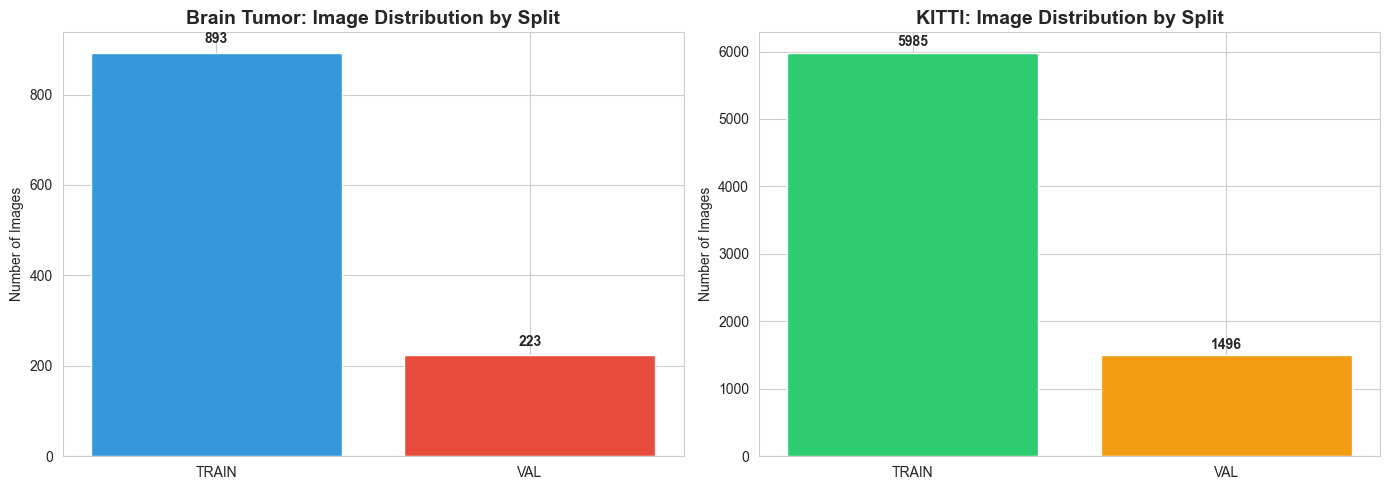

✓ Dataset overview visualization saved


In [5]:
# === BASIC ANALYSIS: Dataset Overview ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bt_data = bt_summary[['Split', 'Images']].set_index('Split')
axes[0].bar(bt_data.index, bt_data['Images'], color=['#3498db', '#e74c3c'])
axes[0].set_title('Brain Tumor: Image Distribution by Split', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(bt_data['Images']):
    axes[0].text(i, v + 20, str(int(v)), ha='center', fontweight='bold')

kt_data = kt_summary[['Split', 'Images']].set_index('Split')
axes[1].bar(kt_data.index, kt_data['Images'], color=['#2ecc71', '#f39c12'])
axes[1].set_title('KITTI: Image Distribution by Split', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(kt_data['Images']):
    axes[1].text(i, v + 100, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '01_dataset_splits_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Dataset overview visualization saved")

Plotting image dimensions: 100%|██████████| 4/4 [00:00<00:00, 102.80it/s]


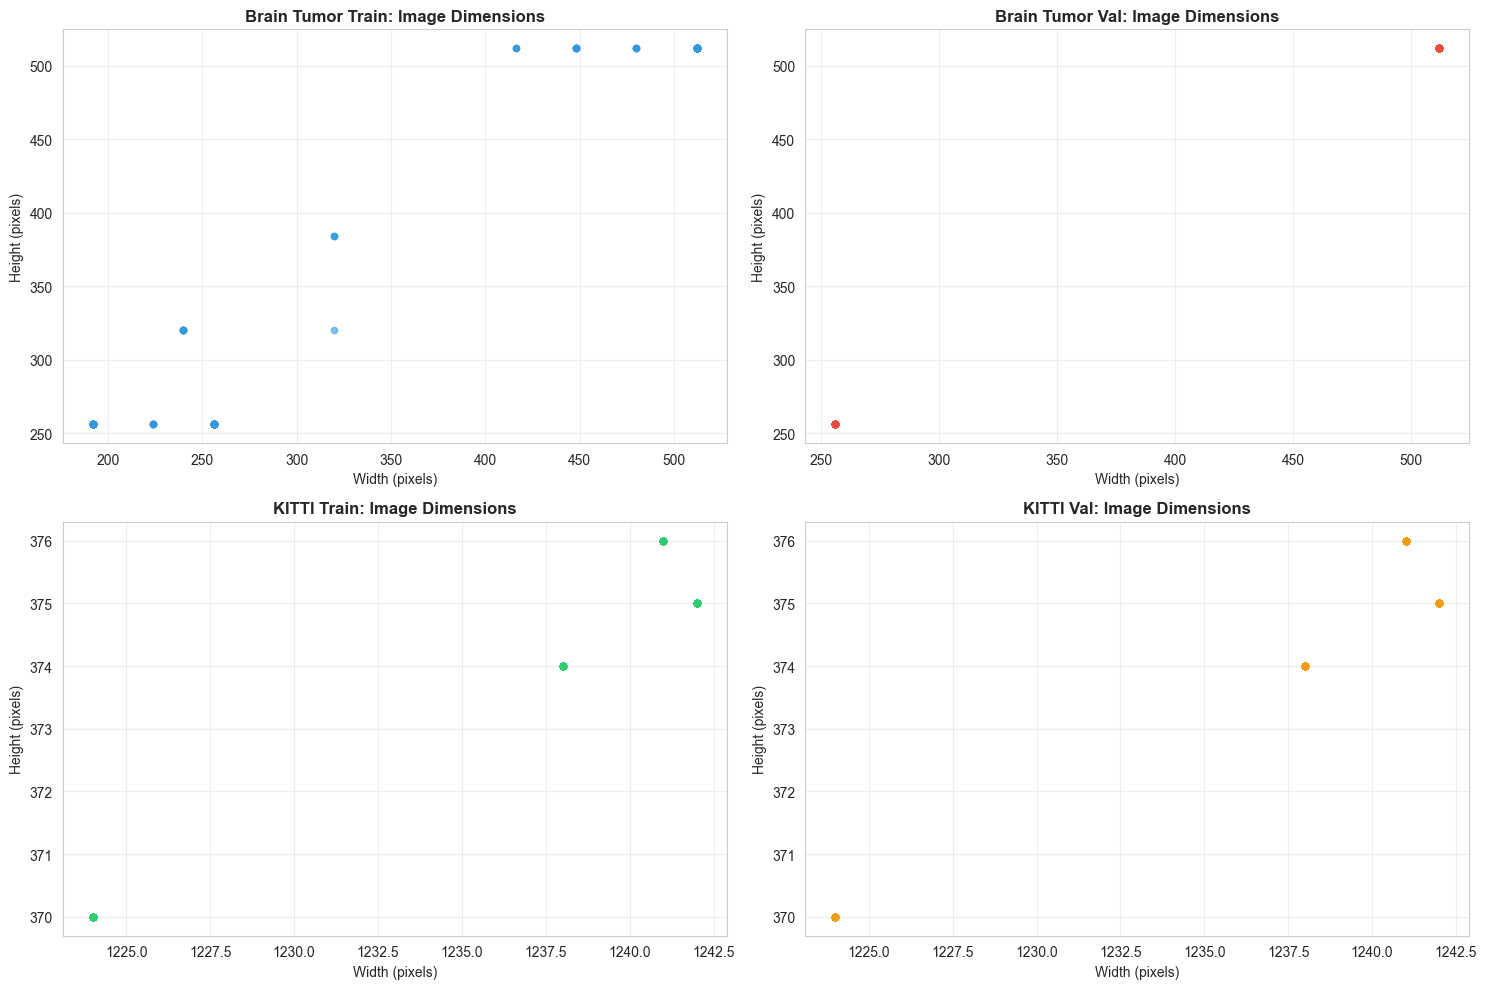

✓ Image dimensions visualization saved


In [6]:
# === ANALYSIS: Image Dimensions ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

dim_configs = [
    (brain_tumor_stats['train']['image_stats'], 'Brain Tumor Train: Image Dimensions', '#3498db', axes[0, 0]),
    (brain_tumor_stats['val']['image_stats'],   'Brain Tumor Val: Image Dimensions',   '#e74c3c', axes[0, 1]),
    (kitti_stats['train']['image_stats'],       'KITTI Train: Image Dimensions',       '#2ecc71', axes[1, 0]),
    (kitti_stats['val']['image_stats'],         'KITTI Val: Image Dimensions',         '#f39c12', axes[1, 1]),
]

for img_stats, title, color, ax in tqdm(dim_configs, desc='Plotting image dimensions'):
    if img_stats:
        ax.scatter([s['width'] for s in img_stats], [s['height'] for s in img_stats],
                   alpha=0.6, s=20, color=color)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Width (pixels)')
        ax.set_ylabel('Height (pixels)')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '02_image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Image dimensions visualization saved")

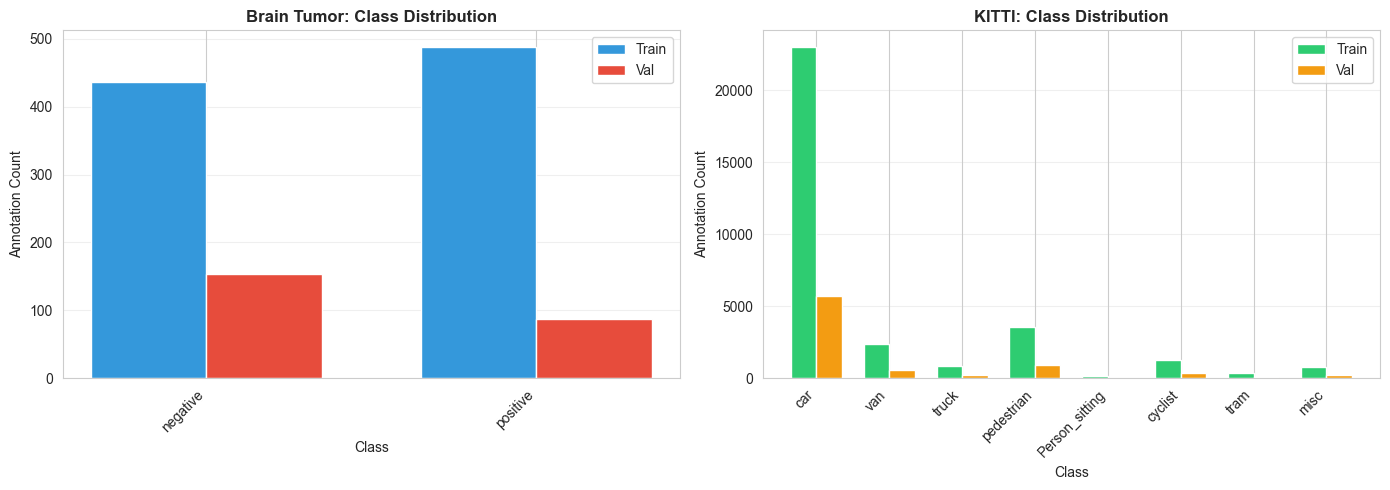

✓ Class distribution visualization saved


In [7]:
# === ANALYSIS: Class Distribution ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bt_train_labels = brain_tumor_stats['train']['labels_data']
bt_val_labels   = brain_tumor_stats['val']['labels_data']
kt_train_labels = kitti_stats['train']['labels_data']
kt_val_labels   = kitti_stats['val']['labels_data']

def plot_class_dist(ax, train_labels, val_labels, class_names, title, colors):
    if not train_labels:
        return
    train_cls = Counter([l['class'] for l in train_labels])
    val_cls   = Counter([l['class'] for l in val_labels])
    x         = np.arange(len(class_names))
    w         = 0.35
    ax.bar(x - w/2, [train_cls.get(i, 0) for i in range(len(class_names))], w, label='Train', color=colors[0])
    ax.bar(x + w/2, [val_cls.get(i, 0)   for i in range(len(class_names))], w, label='Val',   color=colors[1])
    ax.set_xlabel('Class')
    ax.set_ylabel('Annotation Count')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([class_names[i] for i in range(len(class_names))], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plot_class_dist(axes[0], bt_train_labels, bt_val_labels,
                brain_tumor_config['names'], 'Brain Tumor: Class Distribution', ['#3498db', '#e74c3c'])
plot_class_dist(axes[1], kt_train_labels, kt_val_labels,
                kitti_config['names'],       'KITTI: Class Distribution',       ['#2ecc71', '#f39c12'])

plt.tight_layout()
plt.savefig(VISUALS_DIR / '03_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Class distribution visualization saved")

Plotting annotation counts: 100%|██████████| 4/4 [00:00<00:00, 49.74it/s]


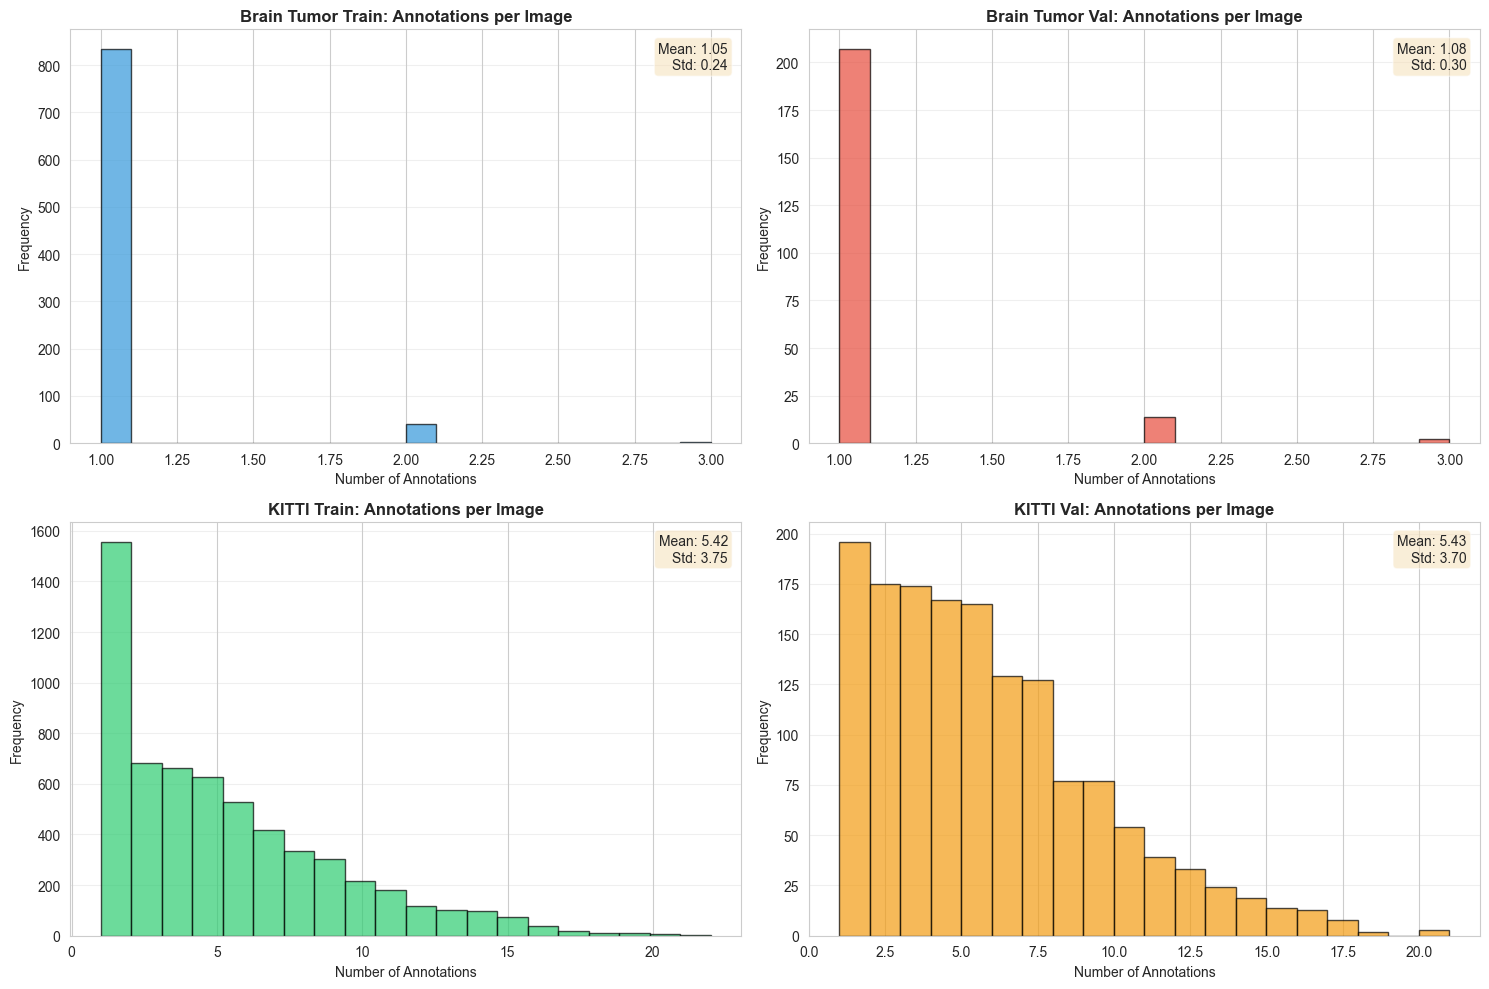

✓ Annotations per image visualization saved


In [8]:
# === ADVANCED ANALYSIS: Annotations per Image ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

annot_configs = [
    (bt_train_labels, 'Brain Tumor Train: Annotations per Image', '#3498db', axes[0, 0]),
    (bt_val_labels,   'Brain Tumor Val: Annotations per Image',   '#e74c3c', axes[0, 1]),
    (kt_train_labels, 'KITTI Train: Annotations per Image',       '#2ecc71', axes[1, 0]),
    (kt_val_labels,   'KITTI Val: Annotations per Image',         '#f39c12', axes[1, 1]),
]

for labels, title, color, ax in tqdm(annot_configs, desc='Plotting annotation counts'):
    if labels:
        counts = list(Counter([l['file'] for l in labels]).values())
        ax.hist(counts, bins=20, color=color, edgecolor='black', alpha=0.7)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Number of Annotations')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3, axis='y')
        ax.text(0.98, 0.97, f'Mean: {np.mean(counts):.2f}\nStd: {np.std(counts):.2f}',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(VISUALS_DIR / '04_annotations_per_image.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Annotations per image visualization saved")

Plotting bbox areas: 100%|██████████| 4/4 [00:00<00:00, 52.37it/s]


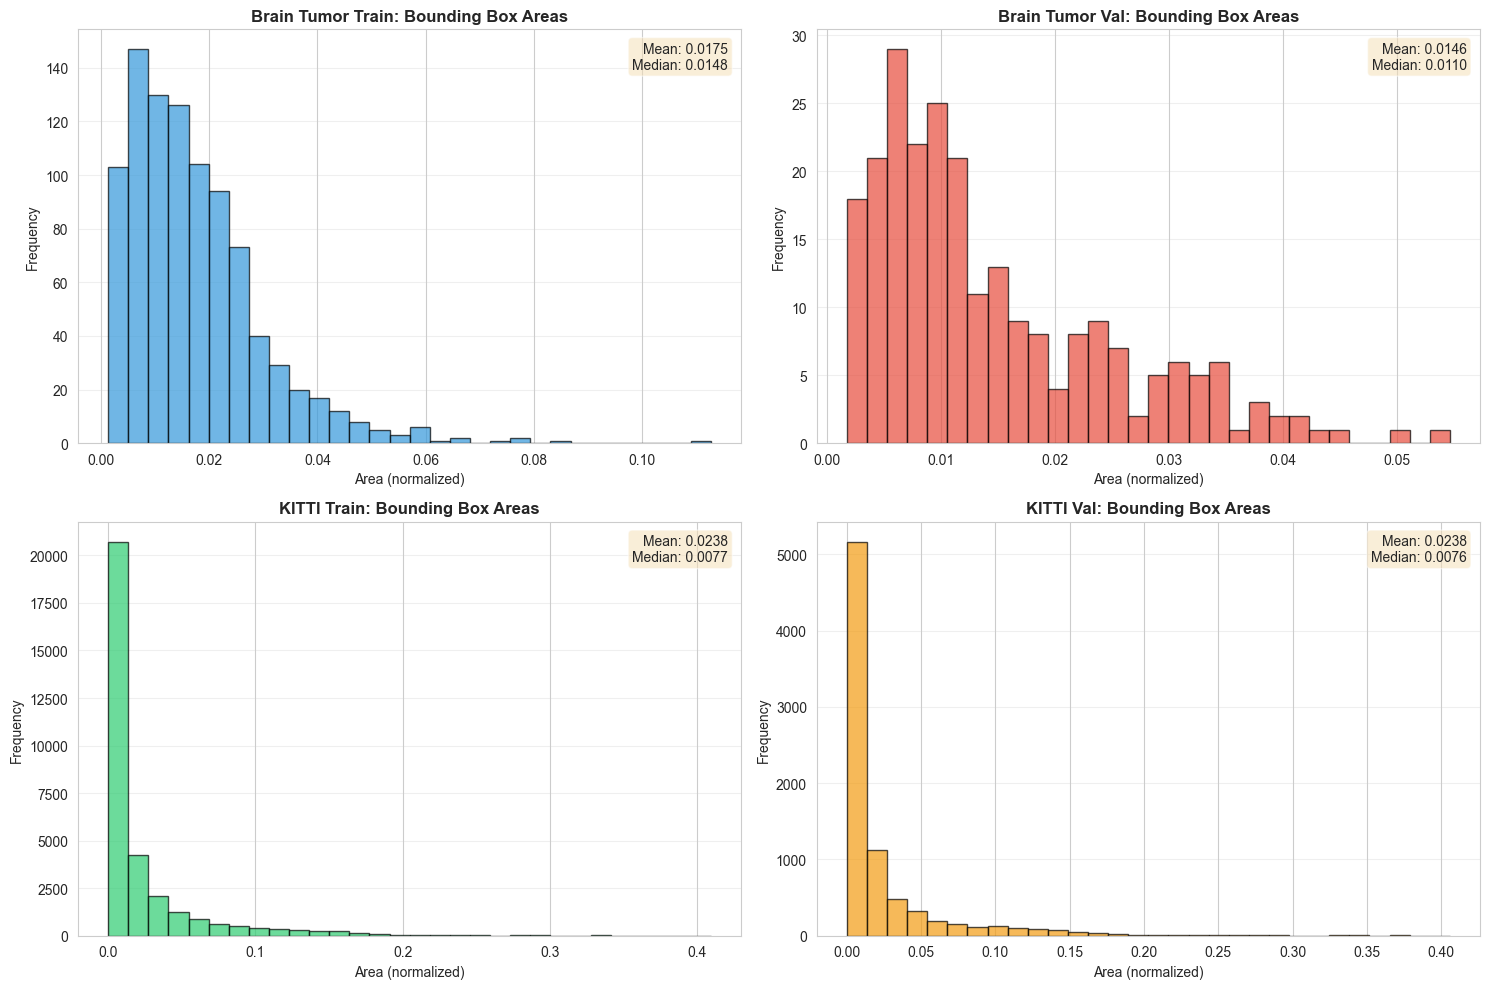

✓ Bounding box sizes visualization saved


In [9]:
# === ADVANCED ANALYSIS: Bounding Box Areas ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

bbox_configs = [
    (bt_train_labels, 'Brain Tumor Train: Bounding Box Areas', '#3498db', axes[0, 0]),
    (bt_val_labels,   'Brain Tumor Val: Bounding Box Areas',   '#e74c3c', axes[0, 1]),
    (kt_train_labels, 'KITTI Train: Bounding Box Areas',       '#2ecc71', axes[1, 0]),
    (kt_val_labels,   'KITTI Val: Bounding Box Areas',         '#f39c12', axes[1, 1]),
]

for labels, title, color, ax in tqdm(bbox_configs, desc='Plotting bbox areas'):
    if labels:
        areas = [l['width'] * l['height'] for l in labels]
        ax.hist(areas, bins=30, color=color, edgecolor='black', alpha=0.7)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Area (normalized)')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3, axis='y')
        ax.text(0.98, 0.97, f'Mean: {np.mean(areas):.4f}\nMedian: {np.median(areas):.4f}',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(VISUALS_DIR / '05_bounding_box_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Bounding box sizes visualization saved")

Plotting BT samples: 100%|██████████| 6/6 [00:00<00:00, 605.30it/s]


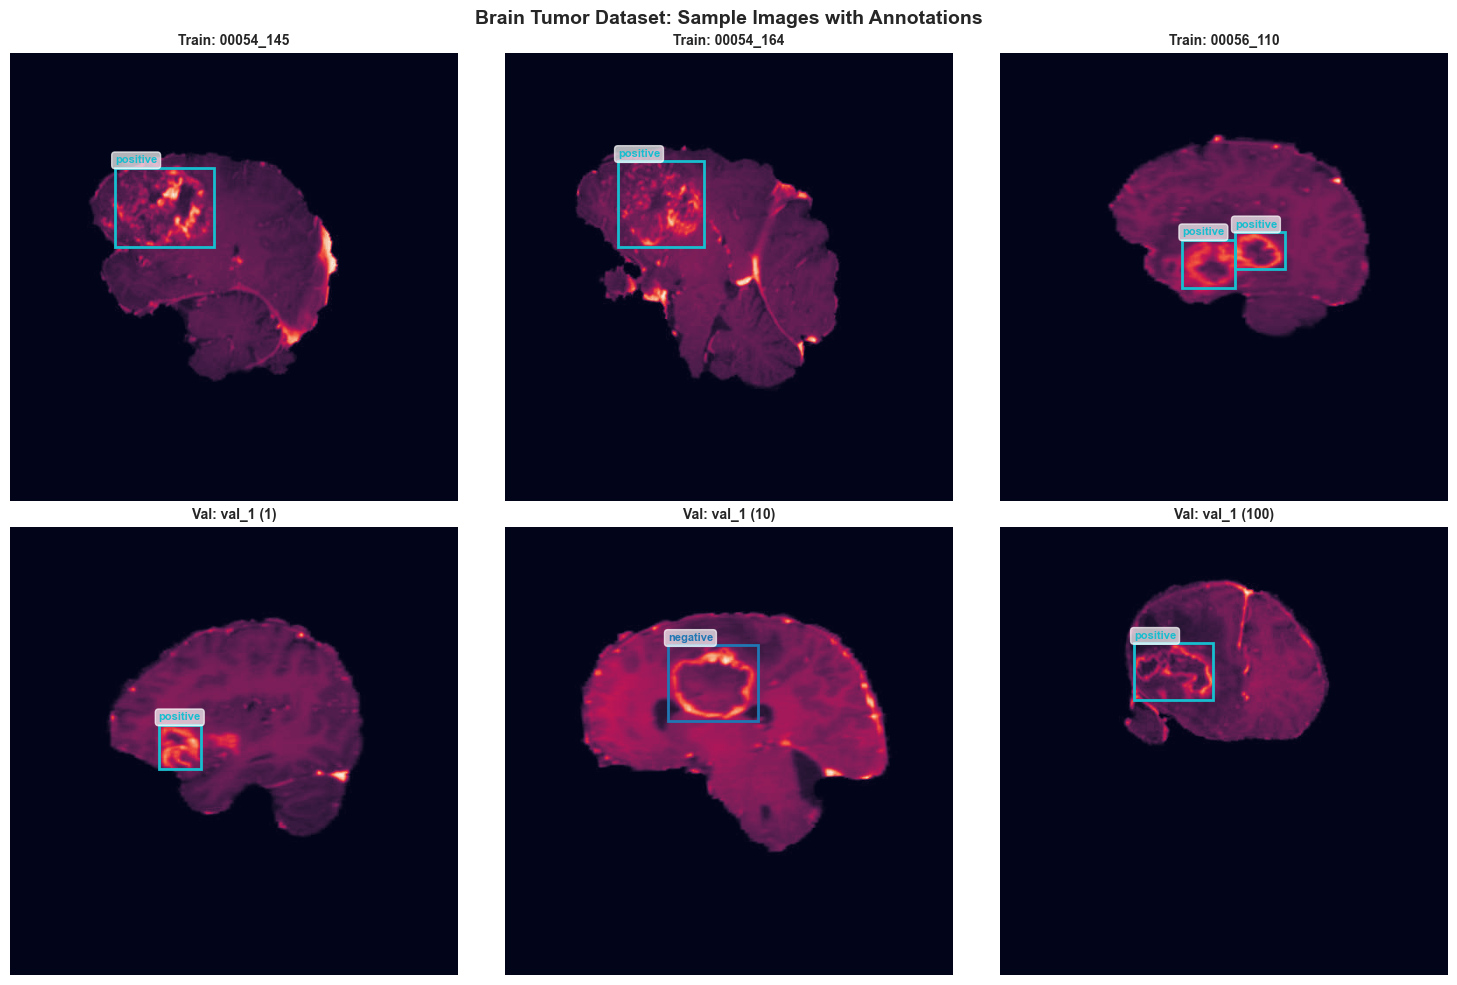

✓ Brain Tumor samples visualization saved


In [10]:
# === VISUALIZATION: Sample Images with Annotations (Brain Tumor) ===

def plot_image_with_bbox(ax, img_path, label_path, class_names, title):
    """Plot image with bounding boxes."""
    try:
        img = Image.open(img_path)
        ax.imshow(img)
        if Path(label_path).exists():
            with open(label_path, 'r') as f:
                lines = f.readlines()
            iw, ih = img.size
            colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
            for line in lines:
                parts = line.strip().split()
                if parts:
                    cid = int(parts[0])
                    xc  = float(parts[1]) * iw
                    yc  = float(parts[2]) * ih
                    w   = float(parts[3]) * iw
                    h   = float(parts[4]) * ih
                    rect = plt.Rectangle((xc - w/2, yc - h/2), w, h,
                                         linewidth=2, edgecolor=colors[cid], facecolor='none')
                    ax.add_patch(rect)
                    ax.text(xc - w/2, yc - h/2 - 5, class_names[cid],
                            color=colors[cid], fontsize=8, fontweight='bold',
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        ax.set_title(title, fontweight='bold', fontsize=10)
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center')
        ax.axis('off')


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Brain Tumor Dataset: Sample Images with Annotations',
             fontsize=14, fontweight='bold', y=0.98)

bt_train_images = get_image_files(BRAIN_TUMOR_DIR / 'images' / 'train')
bt_val_images   = get_image_files(BRAIN_TUMOR_DIR / 'images' / 'val')
bt_class_names  = brain_tumor_config['names']

sample_pairs = (
    [(bt_train_images[i], 'train', f'Train: {bt_train_images[i].stem}') for i in range(min(3, len(bt_train_images)))] +
    [(bt_val_images[i],   'val',   f'Val: {bt_val_images[i].stem}')     for i in range(min(3, len(bt_val_images)))]
)

for idx, (img_file, split, title) in enumerate(tqdm(sample_pairs, desc='Plotting BT samples')):
    row, col   = divmod(idx, 3)
    label_file = BRAIN_TUMOR_DIR / 'labels' / split / f'{img_file.stem}.txt'
    plot_image_with_bbox(axes[row, col], img_file, label_file, bt_class_names, title)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '06_brain_tumor_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Brain Tumor samples visualization saved")

Plotting KITTI samples: 100%|██████████| 6/6 [00:00<00:00, 254.42it/s]


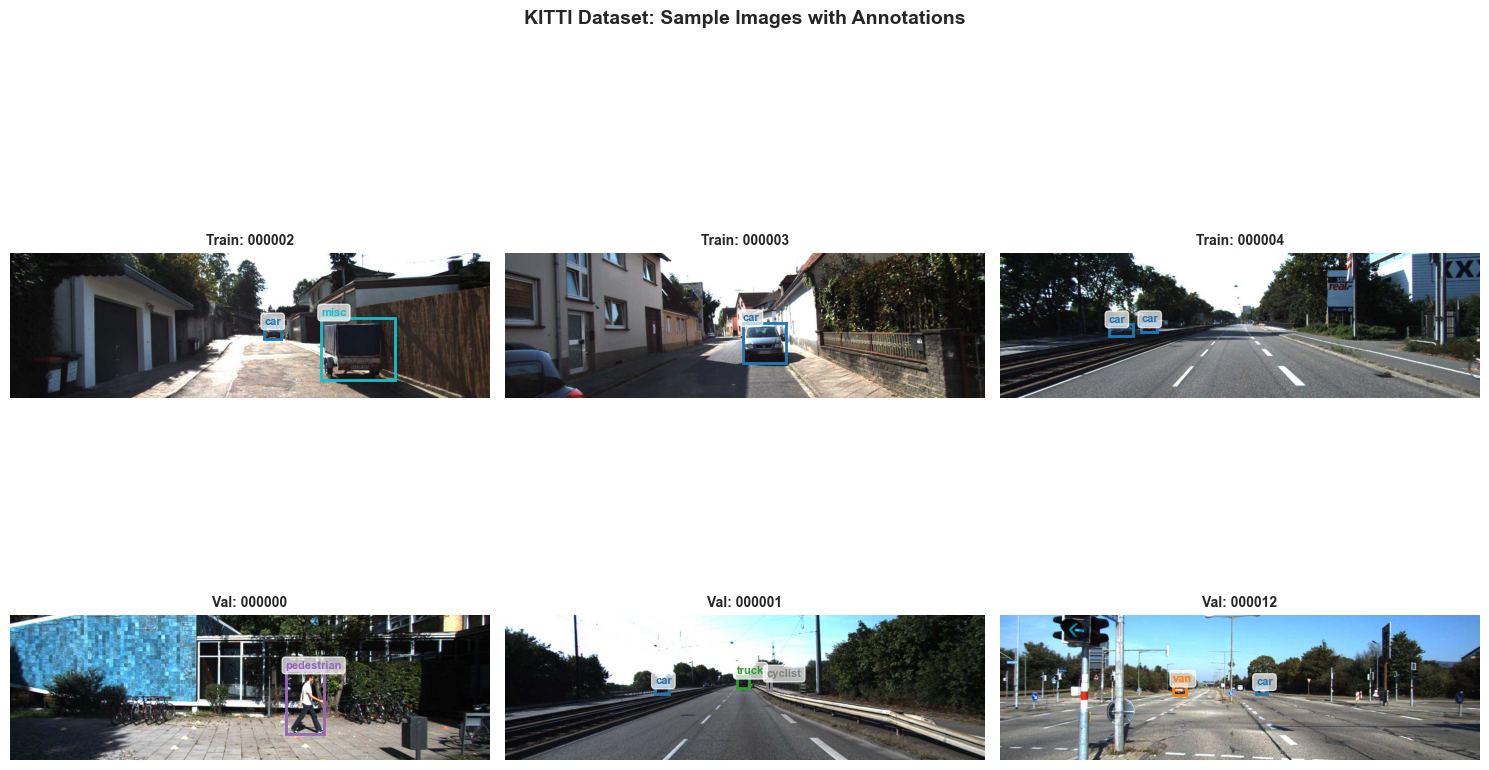

✓ KITTI samples visualization saved


In [11]:
# === VISUALIZATION: Sample Images with Annotations (KITTI) ===

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('KITTI Dataset: Sample Images with Annotations',
             fontsize=14, fontweight='bold', y=0.98)

kt_train_images = get_image_files(KITTI_DIR / 'images' / 'train')
kt_val_images   = get_image_files(KITTI_DIR / 'images' / 'val')
kt_class_names  = kitti_config['names']

kt_sample_pairs = (
    [(kt_train_images[i], 'train', f'Train: {kt_train_images[i].stem}') for i in range(min(3, len(kt_train_images)))] +
    [(kt_val_images[i],   'val',   f'Val: {kt_val_images[i].stem}')     for i in range(min(3, len(kt_val_images)))]
)

for idx, (img_file, split, title) in enumerate(tqdm(kt_sample_pairs, desc='Plotting KITTI samples')):
    row, col   = divmod(idx, 3)
    label_file = KITTI_DIR / 'labels' / split / f'{img_file.stem}.txt'
    plot_image_with_bbox(axes[row, col], img_file, label_file, kt_class_names, title)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '07_kitti_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ KITTI samples visualization saved")

In [12]:
# === NEW ANALYSIS 5: Anchor Box Optimization (K-Means) ===
from sklearn.cluster import KMeans

def calculate_optimal_anchors(stats_data, n_clusters=9):
    boxes = []
    for split in ['train']:
        if split in stats_data:
            for l in stats_data[split]['labels_data']:
                boxes.append([l['width'], l['height']])
    
    if not boxes: return None
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(boxes)
    anchors = kmeans.cluster_centers_
    # Sort by area
    anchors = anchors[np.argsort(anchors[:, 0] * anchors[:, 1])]
    return anchors

print("🚀 Calculating Suggested Anchors (Normalized W, H):")
bt_anchors = calculate_optimal_anchors(brain_tumor_stats)
if bt_anchors is not None:
    print(f"Brain Tumor Suggeted Anchors:\n{bt_anchors}")

🚀 Calculating Suggested Anchors (Normalized W, H):
Brain Tumor Suggeted Anchors:
[[0.06019751 0.05934102]
 [0.08943731 0.08231762]
 [0.10497137 0.11133119]
 [0.14042122 0.10338737]
 [0.12491987 0.14662799]
 [0.16110482 0.14821177]
 [0.21544964 0.15646812]
 [0.17003613 0.19979135]
 [0.24129258 0.25542842]]


In [13]:
# === NEW ANALYSIS 6: COCO Object Scale Distribution ===

def get_coco_metrics(stats_data, dataset_name):
    scales = {'Small (<32²)': 0, 'Medium': 0, 'Large (>96²)': 0}
    # This requires mapping image size to labels to get absolute pixel dimensions
    # Assuming standard input size of 640 for comparison
    for split in ['train', 'val']:
        if split in stats_data:
            for l in stats_data[split]['labels_data']:
                area_px = (l['width'] * 640) * (l['height'] * 640)
                if area_px < 32**2: scales['Small (<32²)'] += 1
                elif area_px < 96**2: scales['Medium'] += 1
                else: scales['Large (>96²)'] += 1
    return scales

# Plotting these as a Bar Chart would show if you have a "Small Object" problem.

In [14]:
# === ADVANCED ANALYSIS: Data Quality & Balance ===

def get_detailed_stats(dataset_stats, config, dataset_name):
    results = []
    for split, split_data in tqdm(dataset_stats.items(), desc=f'Detailed stats {dataset_name}'):
        labels_data = split_data['labels_data']
        if labels_data:
            class_dist = Counter([l['class'] for l in labels_data])
            img_counts = Counter([l['file']  for l in labels_data])
            results.append({
                'Dataset'                    : dataset_name,
                'Split'                      : split.upper(),
                'Total Images'               : split_data['images'],
                'Total Annotations'          : len(labels_data),
                'Images with Annotations'    : len(img_counts),
                'Avg Annotations/Image'      : len(labels_data) / len(img_counts) if img_counts else 0,
                'Min Annotations'            : min(img_counts.values()) if img_counts else 0,
                'Max Annotations'            : max(img_counts.values()) if img_counts else 0,
                'Class Balance (most dominant)': max(class_dist.values()) / len(labels_data) if class_dist else 0
            })
    return pd.DataFrame(results)


bt_detailed = get_detailed_stats(brain_tumor_stats, brain_tumor_config, 'Brain Tumor')
kt_detailed = get_detailed_stats(kitti_stats,       kitti_config,       'KITTI')

print("📊 BRAIN TUMOR: Detailed Statistics")
print(bt_detailed.to_string(index=False))
print("\n📊 KITTI: Detailed Statistics")
print(kt_detailed.to_string(index=False))

Detailed stats KITTI: 100%|██████████| 2/2 [00:00<00:00, 258.36it/s]

📊 BRAIN TUMOR: Detailed Statistics
    Dataset Split  Total Images  Total Annotations  Images with Annotations  Avg Annotations/Image  Min Annotations  Max Annotations  Class Balance (most dominant)
Brain Tumor TRAIN           893                925                      878               1.053531                1                3                       0.527568
Brain Tumor   VAL           223                241                      223               1.080717                1                3                       0.639004

📊 KITTI: Detailed Statistics
Dataset Split  Total Images  Total Annotations  Images with Annotations  Avg Annotations/Image  Min Annotations  Max Annotations  Class Balance (most dominant)
  KITTI TRAIN          5985              32442                     5985               5.420551                1               22                       0.709759
  KITTI   VAL          1496               8128                     1496               5.433155                1            

In [15]:
# === DATA QUALITY CHECKS ===

def check_data_quality(dataset_dir, dataset_name):
    """Comprehensive data quality assessment."""
    issues = []
    for split in tqdm(['train', 'val'], desc=f'Quality check {dataset_name}'):
        img_dir   = dataset_dir / 'images' / split
        label_dir = dataset_dir / 'labels' / split
        if img_dir.exists():
            img_files   = set(f.stem for f in get_image_files(img_dir))
            label_files = set(f.stem for f in label_dir.glob('*.txt')) if label_dir.exists() else set()
            missing_labels   = img_files - label_files
            orphaned_labels  = label_files - img_files
            if missing_labels:
                issues.append(f"  ⚠️  {split.upper()}: {len(missing_labels)} images without labels")
            if orphaned_labels:
                issues.append(f"  ⚠️  {split.upper()}: {len(orphaned_labels)} label files without images")
            if label_dir.exists():
                for lf in label_dir.glob('*.txt'):
                    if lf.stat().st_size == 0:
                        issues.append(f"  ⚠️  {split.upper()}: {lf.name} is empty")
            for img_file in tqdm(get_image_files(img_dir), desc=f'Verifying {split} images', leave=False):
                try:
                    Image.open(img_file).verify()
                except Exception:
                    issues.append(f"  ⚠️  {split.upper()}: {img_file.name} is corrupted")
    return issues if issues else ["  ✓ No issues detected"]


print("🔍 DATA QUALITY ASSESSMENT\n")
print(f"Brain Tumor ({BRAIN_TUMOR_DIR}):")
for issue in check_data_quality(BRAIN_TUMOR_DIR, 'Brain Tumor'):
    print(issue)

print(f"\nKITTI ({KITTI_DIR}):")
for issue in check_data_quality(KITTI_DIR, 'KITTI'):
    print(issue)

🔍 DATA QUALITY ASSESSMENT

Brain Tumor (..\datasets\brain_tumor):


Quality check Brain Tumor: 100%|██████████| 2/2 [00:00<00:00, 16.62it/s]


  ⚠️  TRAIN: 15 images without labels

KITTI (..\datasets\kitti):


Quality check KITTI: 100%|██████████| 2/2 [00:00<00:00,  2.71it/s]

  ✓ No issues detected


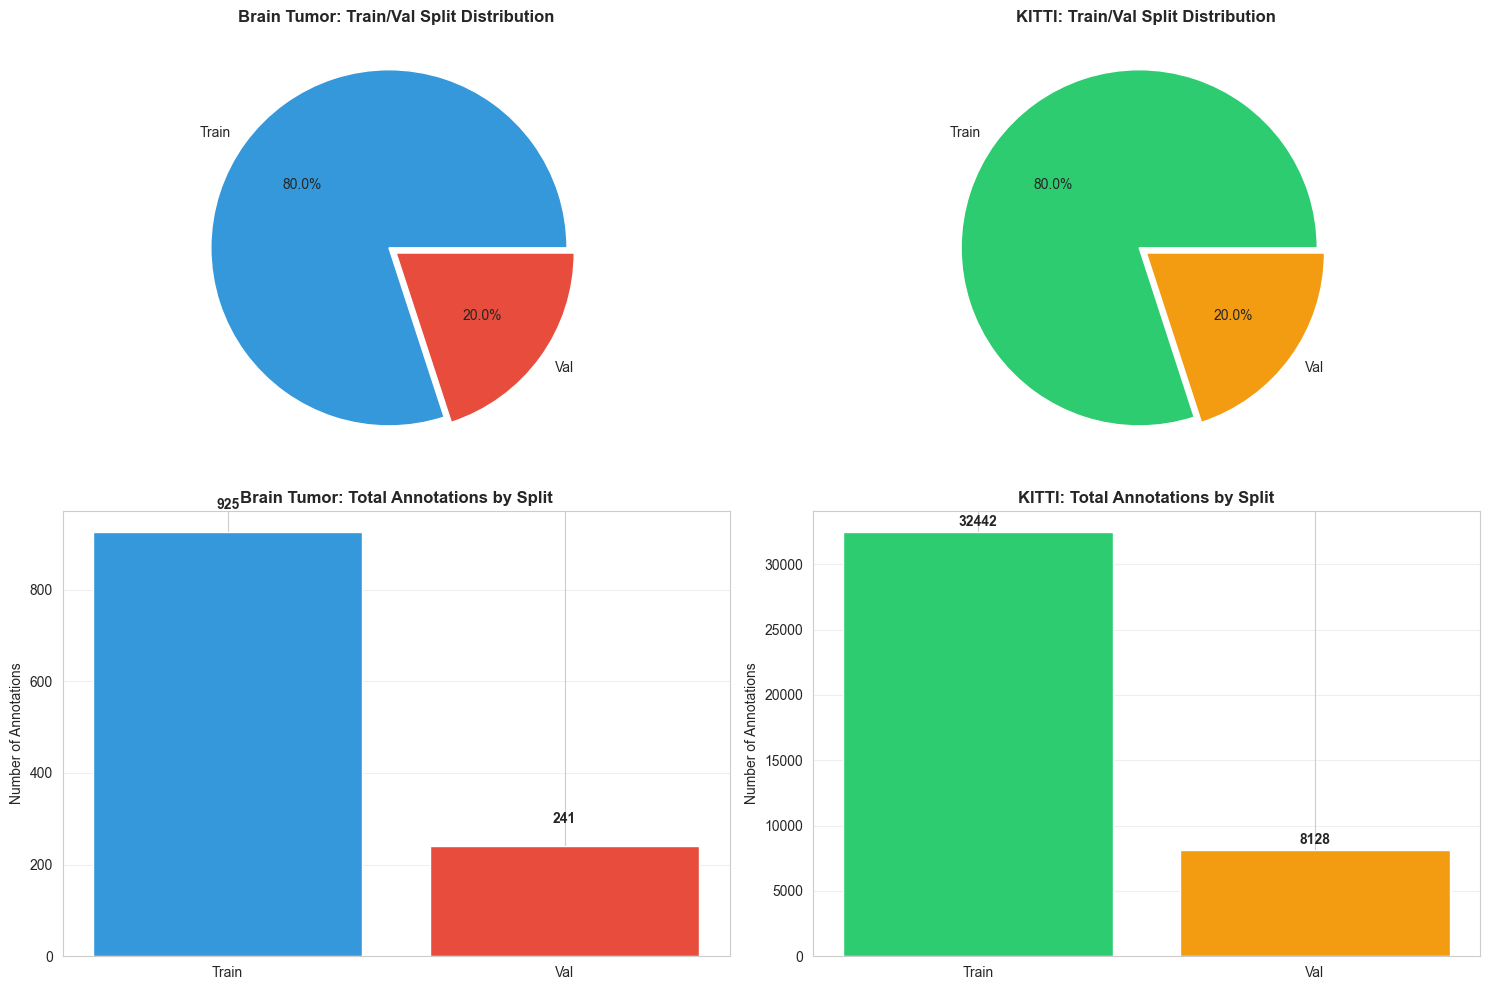

✓ Train/Val comparison visualization saved


In [16]:
# === COMPARATIVE ANALYSIS: Train vs Val Split ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

bt_train_n = bt_summary[bt_summary['Split'] == 'TRAIN']['Images'].values[0]
bt_val_n   = bt_summary[bt_summary['Split'] == 'VAL']['Images'].values[0]
kt_train_n = kt_summary[kt_summary['Split'] == 'TRAIN']['Images'].values[0]
kt_val_n   = kt_summary[kt_summary['Split'] == 'VAL']['Images'].values[0]

axes[0, 0].pie([bt_train_n, bt_val_n], labels=['Train', 'Val'], autopct='%1.1f%%',
               colors=['#3498db', '#e74c3c'], explode=(0.05, 0))
axes[0, 0].set_title('Brain Tumor: Train/Val Split Distribution', fontweight='bold')

axes[0, 1].pie([kt_train_n, kt_val_n], labels=['Train', 'Val'], autopct='%1.1f%%',
               colors=['#2ecc71', '#f39c12'], explode=(0.05, 0))
axes[0, 1].set_title('KITTI: Train/Val Split Distribution', fontweight='bold')

if bt_train_labels and bt_val_labels:
    vals = [len(bt_train_labels), len(bt_val_labels)]
    axes[1, 0].bar(['Train', 'Val'], vals, color=['#3498db', '#e74c3c'])
    axes[1, 0].set_title('Brain Tumor: Total Annotations by Split', fontweight='bold')
    axes[1, 0].set_ylabel('Number of Annotations')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(vals):
        axes[1, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

if kt_train_labels and kt_val_labels:
    vals = [len(kt_train_labels), len(kt_val_labels)]
    axes[1, 1].bar(['Train', 'Val'], vals, color=['#2ecc71', '#f39c12'])
    axes[1, 1].set_title('KITTI: Total Annotations by Split', fontweight='bold')
    axes[1, 1].set_ylabel('Number of Annotations')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(vals):
        axes[1, 1].text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '08_train_val_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Train/Val comparison visualization saved")

Plotting aspect ratios: 100%|██████████| 2/2 [00:00<00:00, 29.65it/s]


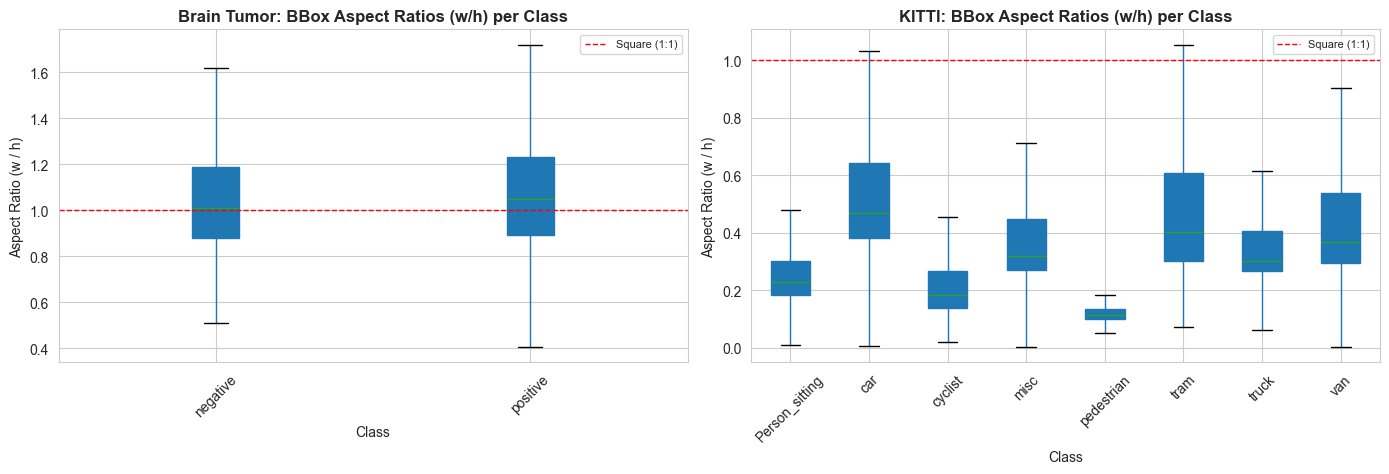

✓ Bounding box aspect ratio visualization saved


In [17]:
# ════════════════════════════════════════════════════════════════════════
# === NEW ANALYSIS 1: Bounding Box Aspect Ratio Distribution ===
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ar_configs = [
    (bt_train_labels + bt_val_labels, brain_tumor_config['names'],
     'Brain Tumor: BBox Aspect Ratios (w/h) per Class', axes[0]),
    (kt_train_labels + kt_val_labels, kitti_config['names'],
     'KITTI: BBox Aspect Ratios (w/h) per Class',       axes[1]),
]

for labels, class_names, title, ax in tqdm(ar_configs, desc='Plotting aspect ratios'):
    if not labels:
        continue
    df_ar = pd.DataFrame(labels)
    df_ar['aspect_ratio'] = df_ar['width'] / df_ar['height'].replace(0, np.nan)
    df_ar['class_name']   = df_ar['class'].map(class_names)
    df_ar.dropna(subset=['aspect_ratio']).boxplot(
        column='aspect_ratio', by='class_name', ax=ax,
        patch_artist=True, showfliers=False
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Aspect Ratio (w / h)')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Square (1:1)')
    ax.legend(fontsize=8)
    plt.suptitle('')  # remove auto suptitle from boxplot

plt.tight_layout()
plt.savefig(VISUALS_DIR / '09_bbox_aspect_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Bounding box aspect ratio visualization saved")

Plotting spatial heatmaps: 100%|██████████| 2/2 [00:00<00:00, 51.41it/s]


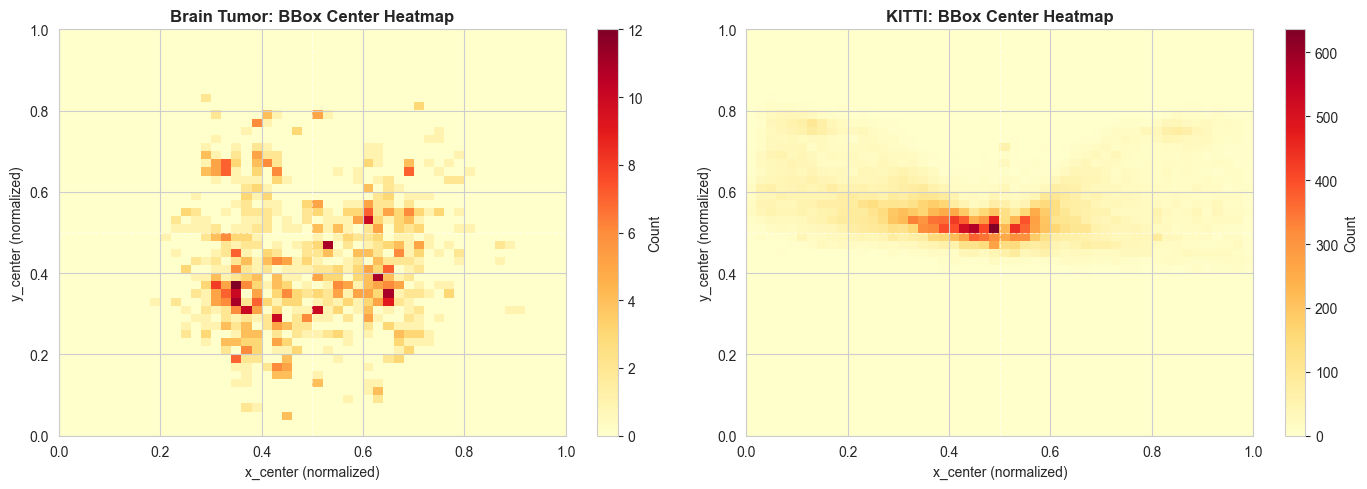

✓ BBox center heatmap saved


In [18]:
# ════════════════════════════════════════════════════════════════════════
# === NEW ANALYSIS 2: Spatial Heatmap of BBox Centers ===
# Shows WHERE in the image objects tend to appear
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heat_configs = [
    (bt_train_labels + bt_val_labels, 'Brain Tumor: BBox Center Heatmap', axes[0]),
    (kt_train_labels + kt_val_labels, 'KITTI: BBox Center Heatmap',       axes[1]),
]

for labels, title, ax in tqdm(heat_configs, desc='Plotting spatial heatmaps'):
    if not labels:
        continue
    xs = [l['x_center'] for l in labels]
    ys = [l['y_center'] for l in labels]
    heatmap, xedges, yedges = np.histogram2d(xs, ys, bins=50, range=[[0,1],[0,1]])
    im = ax.imshow(heatmap.T, origin='lower', aspect='auto',
                   extent=[0, 1, 0, 1], cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label='Count')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x_center (normalized)')
    ax.set_ylabel('y_center (normalized)')
    ax.axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axvline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '10_bbox_center_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ BBox center heatmap saved")

Plotting file sizes: 100%|██████████| 2/2 [00:00<00:00, 65.39it/s]


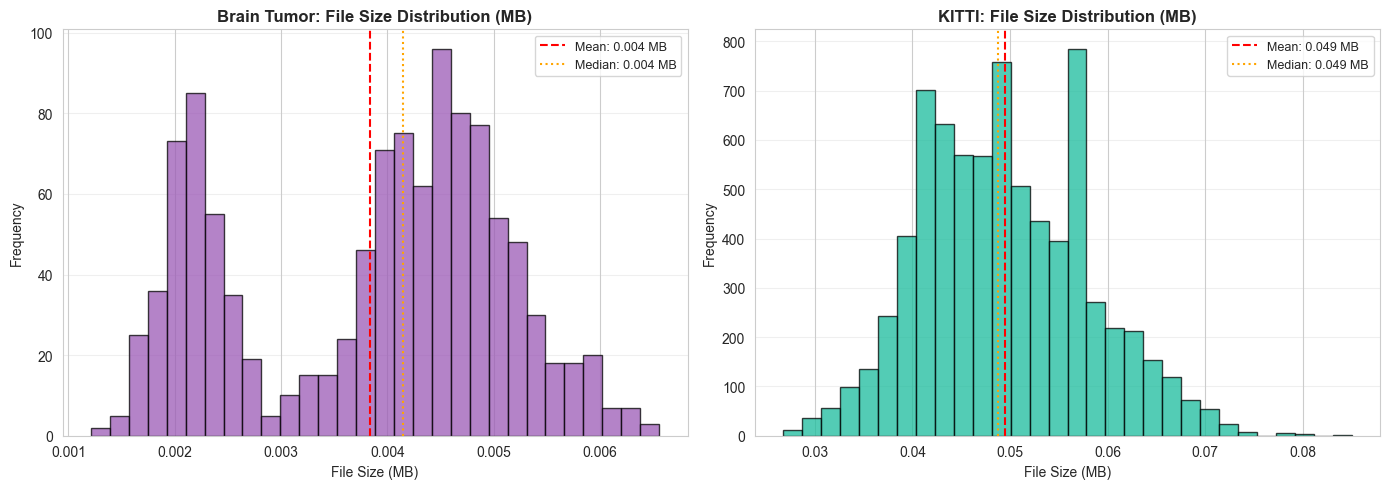

✓ Image file size distribution saved


In [19]:
# ════════════════════════════════════════════════════════════════════════
# === NEW ANALYSIS 3: Image File Size Distribution ===
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

size_configs = [
    (
        brain_tumor_stats['train']['image_stats'] + brain_tumor_stats['val']['image_stats'],
        'Brain Tumor: File Size Distribution (MB)', '#9b59b6', axes[0]
    ),
    (
        kitti_stats['train']['image_stats'] + kitti_stats['val']['image_stats'],
        'KITTI: File Size Distribution (MB)', '#1abc9c', axes[1]
    ),
]

for img_stats, title, color, ax in tqdm(size_configs, desc='Plotting file sizes'):
    if not img_stats:
        continue
    sizes = [s['size_mb'] for s in img_stats]
    ax.hist(sizes, bins=30, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(np.mean(sizes),   color='red',    linestyle='--', label=f'Mean: {np.mean(sizes):.3f} MB')
    ax.axvline(np.median(sizes), color='orange', linestyle=':',  label=f'Median: {np.median(sizes):.3f} MB')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('File Size (MB)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '11_image_file_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Image file size distribution saved")

Computing annotation density: 100%|██████████| 4/4 [00:00<00:00, 746.28it/s]


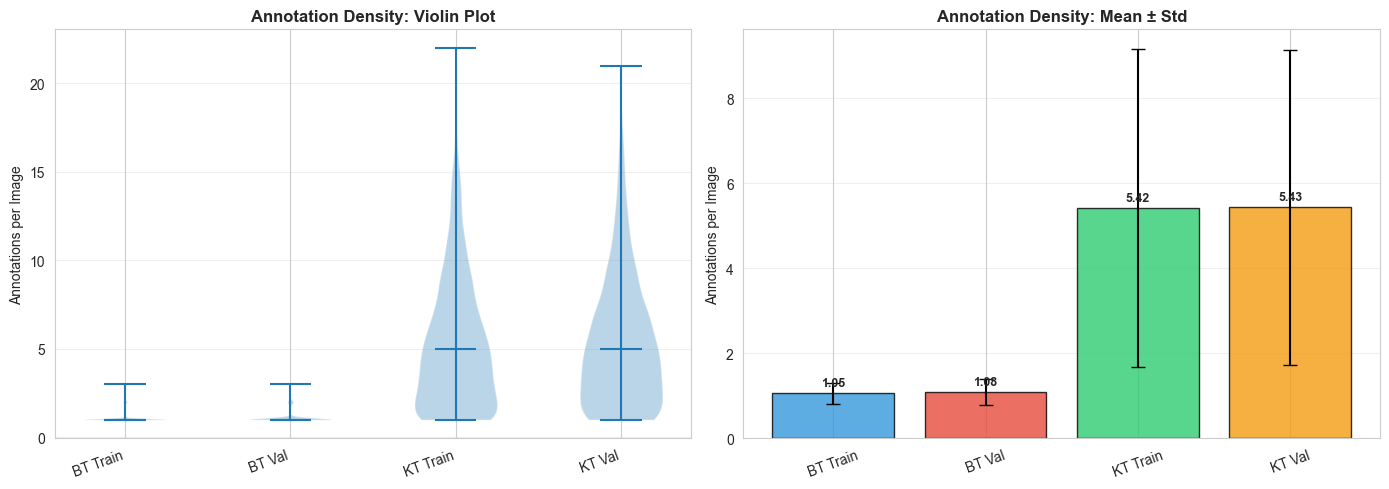

✓ Cross-dataset annotation density comparison saved


In [20]:
# ════════════════════════════════════════════════════════════════════════
# === NEW ANALYSIS 4: Cross-Dataset Annotation Density Comparison ===
# Annotations-per-image across both datasets shown together
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

density_data = {}
for name, labels in tqdm([
        ('BT Train', bt_train_labels), ('BT Val',   bt_val_labels),
        ('KT Train', kt_train_labels), ('KT Val',   kt_val_labels),
    ], desc='Computing annotation density'):
    if labels:
        density_data[name] = list(Counter([l['file'] for l in labels]).values())

# Violin plot — shows full distribution shape
if density_data:
    data_vals  = list(density_data.values())
    data_keys  = list(density_data.keys())
    vp = axes[0].violinplot(data_vals, showmedians=True, showextrema=True)
    axes[0].set_xticks(range(1, len(data_keys) + 1))
    axes[0].set_xticklabels(data_keys, rotation=20, ha='right')
    axes[0].set_title('Annotation Density: Violin Plot', fontweight='bold')
    axes[0].set_ylabel('Annotations per Image')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Mean + std bar chart
    means = [np.mean(v) for v in data_vals]
    stds  = [np.std(v)  for v in data_vals]
    colors_bar = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    bars = axes[1].bar(data_keys, means, yerr=stds, capsize=5,
                       color=colors_bar, edgecolor='black', alpha=0.8)
    axes[1].set_title('Annotation Density: Mean ± Std', fontweight='bold')
    axes[1].set_ylabel('Annotations per Image')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(True, alpha=0.3, axis='y')
    for bar, mean in zip(bars, means):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{mean:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '12_annotation_density_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cross-dataset annotation density comparison saved")

In [21]:
# === SUMMARY & KEY FINDINGS ===

bt_ratio = bt_train_n / (bt_train_n + bt_val_n) * 100 if (bt_train_n + bt_val_n) else 0
kt_ratio = kt_train_n / (kt_train_n + kt_val_n) * 100 if (kt_train_n + kt_val_n) else 0

print("="*80)
print("📋 DATASET ANALYSIS SUMMARY".center(80))
print("="*80)

print("\n🧠 BRAIN TUMOR DATASET")
print("-" * 80)
print(f"  Total Images: {bt_train_n + bt_val_n:,}")
print(f"    - Train: {bt_train_n:,} ({bt_ratio:.1f}%)")
print(f"    - Val:   {bt_val_n:,} ({100-bt_ratio:.1f}%)")
print(f"  Total Annotations: {len(bt_train_labels) + len(bt_val_labels):,}")
print(f"  Classes: {len(brain_tumor_config['names'])} - {', '.join(brain_tumor_config['names'].values())}")
if bt_train_labels:
    bt_all = Counter([l['class'] for l in bt_train_labels + bt_val_labels])
    total  = len(bt_train_labels) + len(bt_val_labels)
    for cid, name in brain_tumor_config['names'].items():
        c = bt_all.get(cid, 0)
        print(f"    - {name}: {c:,} ({c/total*100:.1f}%)")

print("\n🚗 KITTI DATASET")
print("-" * 80)
print(f"  Total Images: {kt_train_n + kt_val_n:,}")
print(f"    - Train: {kt_train_n:,} ({kt_ratio:.1f}%)")
print(f"    - Val:   {kt_val_n:,} ({100-kt_ratio:.1f}%)")
print(f"  Total Annotations: {len(kt_train_labels) + len(kt_val_labels):,}")
print(f"  Classes: {len(kitti_config['names'])} - {', '.join(kitti_config['names'].values())}")
if kt_train_labels:
    kt_all = Counter([l['class'] for l in kt_train_labels + kt_val_labels])
    total  = len(kt_train_labels) + len(kt_val_labels)
    for cid, name in kitti_config['names'].items():
        c = kt_all.get(cid, 0)
        print(f"    - {name}: {c:,} ({c/total*100:.1f}%)")

total_bt = len(bt_train_labels) + len(bt_val_labels)
total_kt = len(kt_train_labels) + len(kt_val_labels)

print("\n💡 KEY INSIGHTS")
print("-" * 80)
print(f"  Brain Tumor: {total_bt:,} annotations over {bt_train_n+bt_val_n} images "
      f"→ avg {total_bt/(bt_train_n+bt_val_n):.2f}/image" if (bt_train_n+bt_val_n) else "")
print(f"  KITTI:       {total_kt:,} annotations over {kt_train_n+kt_val_n} images "
      f"→ avg {total_kt/(kt_train_n+kt_val_n):.2f}/image" if (kt_train_n+kt_val_n) else "")
print(f"\n  Visuals saved to: {VISUALS_DIR.resolve()}")
print("  Charts: 01–08 (original) + 09 aspect ratios, 10 spatial heatmap,")
print("          11 file sizes, 12 annotation density comparison")
print("\n📈 RECOMMENDATIONS")
print("-" * 80)
print("  1. Check chart 10 (heatmap): if BT centers cluster at image center →")
print("     random-crop augmentation will help diversify anchor positions.")
print("  2. Chart 09 (aspect ratios): anchor boxes in your YOLO config should")
print("     match the median per-class aspect ratio for faster convergence.")
print("  3. Chart 12 (density): if KITTI avg >> BT avg, scale your annotation")
print("     loss weights accordingly when training a combined head.")
print("  4. Augmentation: flip + brightness for BT; perspective + mosaic for KITTI.")
print("  5. Weighted loss: apply class frequency weights for KITTI's 8-class head.")
print("=" * 80)

                           📋 DATASET ANALYSIS SUMMARY                           

🧠 BRAIN TUMOR DATASET
--------------------------------------------------------------------------------
  Total Images: 1,116
    - Train: 893 (80.0%)
    - Val:   223 (20.0%)
  Total Annotations: 1,166
  Classes: 2 - negative, positive
    - negative: 591 (50.7%)
    - positive: 575 (49.3%)

🚗 KITTI DATASET
--------------------------------------------------------------------------------
  Total Images: 7,481
    - Train: 5,985 (80.0%)
    - Val:   1,496 (20.0%)
  Total Annotations: 40,570
  Classes: 8 - car, van, truck, pedestrian, Person_sitting, cyclist, tram, misc
    - car: 28,742 (70.8%)
    - van: 2,914 (7.2%)
    - truck: 1,094 (2.7%)
    - pedestrian: 4,487 (11.1%)
    - Person_sitting: 222 (0.5%)
    - cyclist: 1,627 (4.0%)
    - tram: 511 (1.3%)
    - misc: 973 (2.4%)

💡 KEY INSIGHTS
--------------------------------------------------------------------------------
  Brain Tumor: 1,166 annotations